# Clasificación de salarios: salario bajo vs salario alto

## Propósito del trabajo

En el notebook anterior trabajamos el problema como **regresión**, es decir, intentamos predecir el valor exacto del salario en USD.

En este nuevo notebook cambiaremos el paradigma: vamos a convertir el problema en una tarea de **clasificación**.

La pregunta ahora será:

> A partir de las características laborales de una persona, ¿el salario pertenece al grupo de **salario bajo** o al grupo de **salario alto**?

Este enfoque es útil cuando no necesitamos estimar el salario exacto, sino clasificar casos en grupos para segmentación o comparación de perfiles laborales.

## Aplicaciones posibles del modelo de clasificación salarial

Este trabajo puede aplicarse como un modelo exploratorio para clasificar perfiles laborales en dos categorías: **salario_bajo** y **salario_alto**. Algunas aplicaciones posibles son:

- **Orientación profesional:**  
  Permite que una persona explore qué tipos de perfiles laborales suelen estar asociados con salarios altos o bajos en el área de datos e inteligencia artificial.

- **Planeación de carrera:**  
  Ayuda a comparar rutas profesionales como Data Analyst, Data Scientist, Data Engineer o Machine Learning Engineer, observando cuáles perfiles se relacionan más con rangos salariales altos.

- **Apoyo a estudiantes o egresados:**  
  Permite que estudiantes próximos a graduarse simulen perfiles laborales y analicen cómo variables como experiencia, cargo, país, trabajo remoto y tamaño de empresa pueden influir en la clasificación salarial.

- **Análisis del mercado laboral:**  
  Ayuda a identificar patrones generales sobre qué características laborales aparecen más asociadas con salarios altos dentro de la base de datos.

- **Diseño de programas de formación:**  
  Puede servir como apoyo para que instituciones educativas identifiquen qué perfiles del mercado parecen tener mejores oportunidades salariales y orienten mejor sus cursos, diplomados o bootcamps.

- **Comparación de ofertas laborales:**  
  Permite analizar si una oferta de empleo se parece más a perfiles de salario bajo o a perfiles de salario alto, según sus características.

- **Apoyo exploratorio a reclutamiento:**  
  Puede servir como referencia inicial para entender qué combinaciones de cargo, experiencia, modalidad de trabajo, país y tamaño de empresa suelen asociarse con distintos rangos salariales.

- **Simulador educativo:**  
  Permite construir una pequeña aplicación donde el usuario ingrese un perfil laboral y el sistema clasifique ese perfil como **salario_bajo** o **salario_alto**.

- **Toma de decisiones basada en datos:**  
  Ayuda a mostrar cómo los datos pueden apoyar decisiones relacionadas con formación, búsqueda laboral, análisis de perfiles y comprensión del mercado.

- **Comprensión práctica de clasificación supervisada:**  
  Sirve para que los estudiantes entiendan cómo un problema numérico, como el salario, puede transformarse en un problema de clasificación mediante un criterio definido, en este caso la mediana.


## 1. Importar librerías

Usaremos librerías básicas de análisis de datos, visualización y aprendizaje automático.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

#conectar con drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Cargar la base de datos limpia

La base ya está limpia y contiene información sobre salarios en áreas de ciencia de datos e inteligencia artificial.


In [2]:
# Esta celda intenta encontrar el CSV en la misma carpeta del notebook o en /mnt/data.
df = pd.read_csv("/content/drive/MyDrive/bootcamp_ia_2026-1/ds_salaries_limpia.csv")

df.head()


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [3]:
df.shape

(565, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           565 non-null    int64 
 1   experience_level    565 non-null    object
 2   employment_type     565 non-null    object
 3   job_title           565 non-null    object
 4   salary_in_usd       565 non-null    int64 
 5   employee_residence  565 non-null    object
 6   remote_ratio        565 non-null    int64 
 7   company_location    565 non-null    object
 8   company_size        565 non-null    object
dtypes: int64(3), object(6)
memory usage: 39.9+ KB


## 3. Definir la variable objetivo para clasificación

La variable original `salary_in_usd` es numérica. Para convertir el problema en clasificación, vamos a crear una nueva variable llamada `clase_salario`.

### Criterio usado

Usaremos la **mediana** como punto de corte.

La mediana divide los datos en dos partes aproximadamente iguales:

- valores menores o iguales a la mediana: **salario bajo**;
- valores mayores que la mediana: **salario alto**.

Este criterio es adecuado para una práctica exploratoria porque permite obtener dos clases balanceadas.


In [4]:
mediana_salario = df['salary_in_usd'].median()
mediana_salario

100000.0

In [5]:
cantidad_en_mediana = (df['salary_in_usd'] == mediana_salario).sum()

print(f'Mediana del salario en USD: {mediana_salario:,.0f}')
print(f'Cantidad de registros exactamente iguales a la mediana: {cantidad_en_mediana}')

Mediana del salario en USD: 100,000
Cantidad de registros exactamente iguales a la mediana: 13


In [6]:
df['clase_salario'] = np.where(
    df['salary_in_usd'] <= mediana_salario,
    1,
    2
)

df['nombre_clase_salario'] = df['clase_salario'].map({
    1: 'salario_bajo',
    2: 'salario_alto'
})

df[['salary_in_usd', 'clase_salario', 'nombre_clase_salario']].head(10)

,salary_in_usd,clase_salario,nombre_clase_salario
0,79833,1,salario_bajo
1,260000,2,salario_alto
2,109024,2,salario_alto
3,20000,1,salario_bajo
4,150000,2,salario_alto
5,72000,1,salario_bajo
6,190000,2,salario_alto
7,35735,1,salario_bajo
8,135000,2,salario_alto
9,125000,2,salario_alto


La codificación usada será:

| Etiqueta | Clase |
|---|---|
| 1 | salario_bajo |
| 2 | salario_alto |


## 4. Revisar el balanceo de las clases

Antes de entrenar modelos de clasificación, es importante revisar si una clase domina demasiado a la otra.

Si una clase tiene muchos más registros que la otra, el modelo puede aprender a favorecer siempre a la clase mayoritaria.


In [7]:
balanceo = (
    df['nombre_clase_salario']
    .value_counts()
    .rename_axis('clase')
    .reset_index(name='cantidad')
)

balanceo['porcentaje'] = balanceo['cantidad'] / len(df) * 100
balanceo

,clase,cantidad,porcentaje
0,salario_bajo,290,51.3274
1,salario_alto,275,48.6726


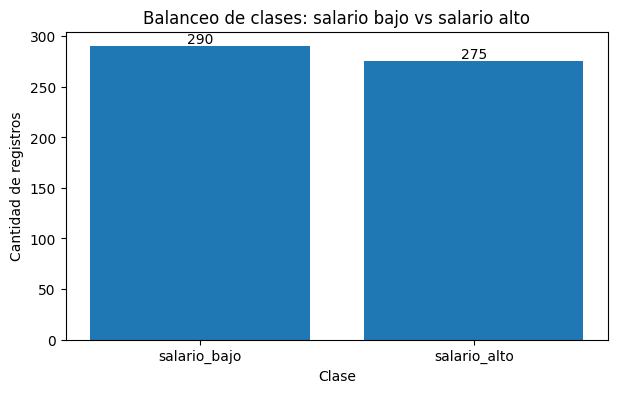

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(balanceo['clase'], balanceo['cantidad'])
plt.title('Balanceo de clases: salario bajo vs salario alto')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')

for i, valor in enumerate(balanceo['cantidad']):
    plt.text(i, valor + 3, str(valor), ha='center')

plt.show()

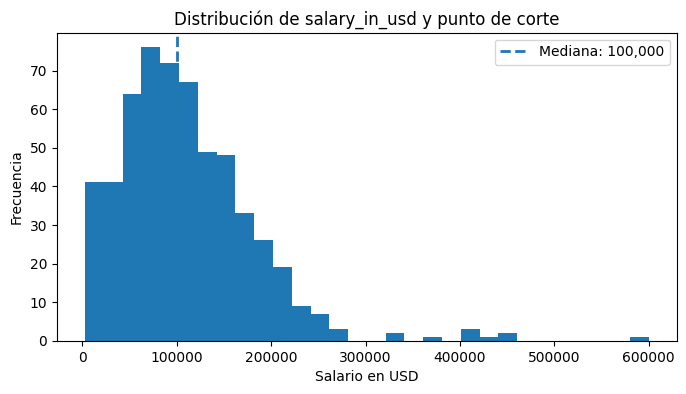

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df['salary_in_usd'], bins=30)
plt.axvline(mediana_salario, linestyle='--', linewidth=2, label=f'Mediana: {mediana_salario:,.0f}')
plt.title('Distribución de salary_in_usd y punto de corte')
plt.xlabel('Salario en USD')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Conclusión sobre el balanceo

Las dos clases quedan bastante equilibradas. Por eso, para este ejercicio no es necesario aplicar técnicas de balanceo artificial como submuestreo, sobremuestreo o SMOTE.


## 5. Separar variables predictoras y variable objetivo

Ahora separamos:

- `X`: variables de entrada o características.
- `y`: variable objetivo clasificada.

Es muy importante eliminar `salary_in_usd` de las variables de entrada, porque esa columna fue usada para crear la clase. Si se dejara, el modelo tendría la respuesta directa y sería una forma de fuga de información.


In [10]:
X = df.drop(columns=['salary_in_usd', 'clase_salario', 'nombre_clase_salario'])
y = df['clase_salario']

X.head()

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,US,50,US,L


In [11]:
y.value_counts()

,count
clase_salario,
1,290
2,275


## 6. Partición de los datos

Dividiremos los datos en:

- 80 % para entrenamiento.
- 20 % para prueba.

Usamos `stratify=y` para conservar la proporción de salarios bajos y altos en ambos conjuntos.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Tamaño X_train:', X_train.shape)
print('Tamaño X_test:', X_test.shape)
print('\nDistribución en entrenamiento:')
print(y_train.value_counts())
print('\nDistribución en prueba:')
print(y_test.value_counts())

Tamaño X_train: (452, 8)
Tamaño X_test: (113, 8)

Distribución en entrenamiento:
clase_salario
1    232
2    220
Name: count, dtype: int64

Distribución en prueba:
clase_salario
1    58
2    55
Name: count, dtype: int64


## 7. Preprocesamiento único para todos los modelos

Para evitar confusiones, usaremos **un solo preprocesamiento** para todos los modelos.

La regla será:

- Las variables **nominales** se transforman con `OneHotEncoder`, porque no tienen un orden natural.
- Las variables **ordinales** se transforman con `OrdinalEncoder`, porque sí tienen un orden lógico.
- El año `work_year` se deja pasar sin transformación, porque ya es numérico y en este ejercicio no se va a escalar.

Esto permite que Regresión Logística, Árbol de Decisión, Random Forest y SVC trabajen con la misma versión de los datos.


In [14]:
variables_ordinales = [
    'experience_level',
    'company_size',
    'remote_ratio'
]

categorias_ordinales = [
    ['EN', 'MI', 'SE', 'EX'],   # nivel de experiencia: entrada, medio, senior, ejecutivo
    ['S', 'M', 'L'],            # tamaño de empresa: pequeña, mediana, grande
    [0, 50, 100]                # modalidad: presencial, híbrido, remoto
]

variables_nominales = [
    'employment_type',
    'job_title',
    'employee_residence',
    'company_location'
]

variables_numericas = [
    'work_year'
]

resumen_preprocesamiento = pd.DataFrame({
    'tipo_de_variable': ['Ordinal', 'Ordinal', 'Ordinal', 'Nominal', 'Nominal', 'Nominal', 'Nominal', 'Numérica'],
    'columna': [
        'experience_level',
        'company_size',
        'remote_ratio',
        'employment_type',
        'job_title',
        'employee_residence',
        'company_location',
        'work_year'
    ],
    'transformacion': [
        'OrdinalEncoder',
        'OrdinalEncoder',
        'OrdinalEncoder',
        'OneHotEncoder',
        'OneHotEncoder',
        'OneHotEncoder',
        'OneHotEncoder',
        'Passthrough / sin transformación'
    ]
})

resumen_preprocesamiento


,tipo_de_variable,columna,transformacion
0,Ordinal,experience_level,OrdinalEncoder
1,Ordinal,company_size,OrdinalEncoder
2,Ordinal,remote_ratio,OrdinalEncoder
3,Nominal,employment_type,OneHotEncoder
4,Nominal,job_title,OneHotEncoder
5,Nominal,employee_residence,OneHotEncoder
6,Nominal,company_location,OneHotEncoder
7,Numérica,work_year,Passthrough / sin transformación


In [15]:
preprocesamiento_unico = ColumnTransformer(
    transformers=[
        ('ordinales', OrdinalEncoder(
            categories=categorias_ordinales,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), variables_ordinales),

        ('nominales', OneHotEncoder(handle_unknown='ignore'), variables_nominales),

        ('numericas', 'passthrough', variables_numericas)
    ]
)

preprocesamiento_unico


ColumnTransformer(transformers=[('ordinales',
                                 OrdinalEncoder(categories=[['EN', 'MI', 'SE',
                                                             'EX'],
                                                            ['S', 'M', 'L'],
                                                            [0, 50, 100]],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['experience_level', 'company_size',
                                  'remote_ratio']),
                                ('nominales',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['employment_type', 'job_title',
                                  'employee_residence', 'company_location']),
                                ('numericas', 'passthrough', ['work_year'])])

## 8. Definir modelos de clasificación

Aplicaremos cuatro modelos:

1. **Regresión Logística**
2. **Árbol de Decisión**
3. **Random Forest**
4. **SVC**

La idea no es usar muchos modelos, sino comparar unos pocos modelos representativos y entender cómo se comportan.

Todos usarán el mismo preprocesamiento para que la comparación sea clara. En el caso de SVC se deja un valor pequeño de `gamma`, porque no estamos aplicando escalado y queremos evitar que el modelo quede demasiado sensible a las distancias.


In [16]:
modelos = {
    'Regresión Logística': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', LogisticRegression(
            C=0.05,
            max_iter=5000,
            random_state=42
        ))
    ]),

    'Árbol de Decisión': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', DecisionTreeClassifier(
            max_depth=7,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=1
        ))
    ]),

    'SVC': Pipeline(steps=[
        ('preprocesamiento', preprocesamiento_unico),
        ('modelo', SVC(
            kernel='rbf',
            C=10,
            gamma=0.001,
            probability=True,
            random_state=42
        ))
    ])
}


## 9. Entrenar modelos y calcular métricas

La métrica principal será **accuracy**, que indica el porcentaje total de clasificaciones correctas.

También revisaremos la matriz de confusión, porque permite ver cuántos casos de salario bajo y salario alto fueron clasificados correctamente o incorrectamente.


In [17]:
resultados = []
predicciones = {}
matrices_confusion = {}

for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[1, 2])

    acierto_etiqueta_1 = cm[0, 0] / cm[0].sum()
    acierto_etiqueta_2 = cm[1, 1] / cm[1].sum()

    resultados.append({
        'modelo': nombre,
        'accuracy': acc,
        'acierto_etiqueta_1_salario_bajo': acierto_etiqueta_1,
        'acierto_etiqueta_2_salario_alto': acierto_etiqueta_2,
        'correctos_salario_bajo': cm[0, 0],
        'bajos_clasificados_como_altos': cm[0, 1],
        'altos_clasificados_como_bajos': cm[1, 0],
        'correctos_salario_alto': cm[1, 1]
    })

    predicciones[nombre] = y_pred
    matrices_confusion[nombre] = cm

resultados_df = pd.DataFrame(resultados).sort_values('accuracy', ascending=False)

resultados_porcentaje = resultados_df.copy()
columnas_porcentaje = [
    'accuracy',
    'acierto_etiqueta_1_salario_bajo',
    'acierto_etiqueta_2_salario_alto'
]

resultados_porcentaje[columnas_porcentaje] = resultados_porcentaje[columnas_porcentaje] * 100
resultados_porcentaje[columnas_porcentaje] = resultados_porcentaje[columnas_porcentaje].round(2)

resultados_porcentaje


,modelo,accuracy,acierto_etiqueta_1_salario_bajo,acierto_etiqueta_2_salario_alto,correctos_salario_bajo,bajos_clasificados_como_altos,altos_clasificados_como_bajos,correctos_salario_alto
1,Árbol de Decisión,85.8400,87.9300,83.6400,51,7,9,46
3,SVC,84.9600,86.2100,83.6400,50,8,9,46
0,Regresión Logística,84.0700,84.4800,83.6400,49,9,9,46
2,Random Forest,84.0700,87.9300,80.0000,51,7,11,44


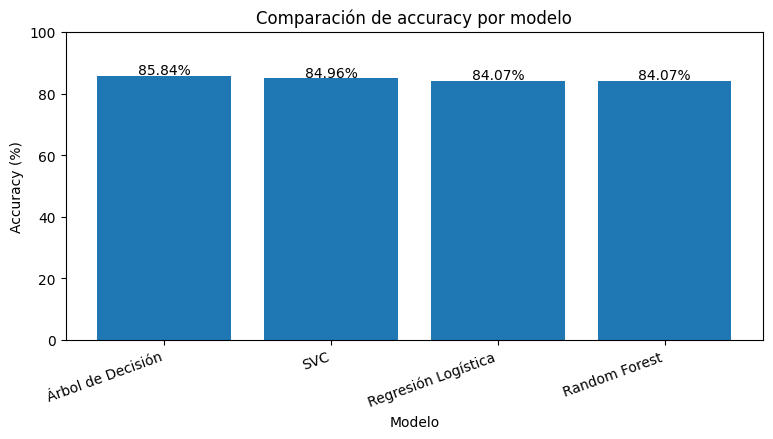

In [18]:
plt.figure(figsize=(9, 4))
plt.bar(resultados_porcentaje['modelo'], resultados_porcentaje['accuracy'])
plt.title('Comparación de accuracy por modelo')
plt.xlabel('Modelo')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20, ha='right')

for i, valor in enumerate(resultados_porcentaje['accuracy']):
    plt.text(i, valor + 0.5, f'{valor:.2f}%', ha='center')

plt.ylim(0, 100)
plt.show()

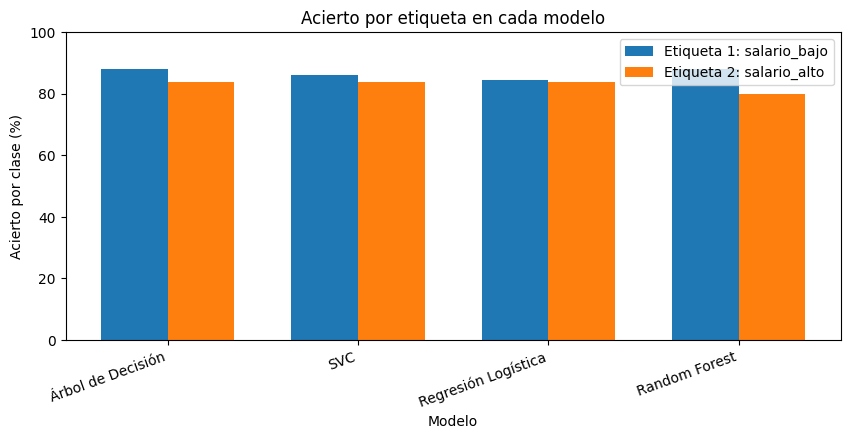

In [19]:
comparacion_clases = resultados_porcentaje[
    ['modelo', 'acierto_etiqueta_1_salario_bajo', 'acierto_etiqueta_2_salario_alto']
].copy()

x = np.arange(len(comparacion_clases))
ancho = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - ancho/2, comparacion_clases['acierto_etiqueta_1_salario_bajo'], width=ancho, label='Etiqueta 1: salario_bajo')
plt.bar(x + ancho/2, comparacion_clases['acierto_etiqueta_2_salario_alto'], width=ancho, label='Etiqueta 2: salario_alto')

plt.title('Acierto por etiqueta en cada modelo')
plt.xlabel('Modelo')
plt.ylabel('Acierto por clase (%)')
plt.xticks(x, comparacion_clases['modelo'], rotation=20, ha='right')
plt.ylim(0, 100)
plt.legend()
plt.show()

## 10. Matrices de confusión

En cada matriz:

- las filas representan la clase real;
- las columnas representan la clase predicha.

La diagonal principal muestra los aciertos.

| Etiqueta | Clase |
|---|---|
| 1 | salario_bajo |
| 2 | salario_alto |


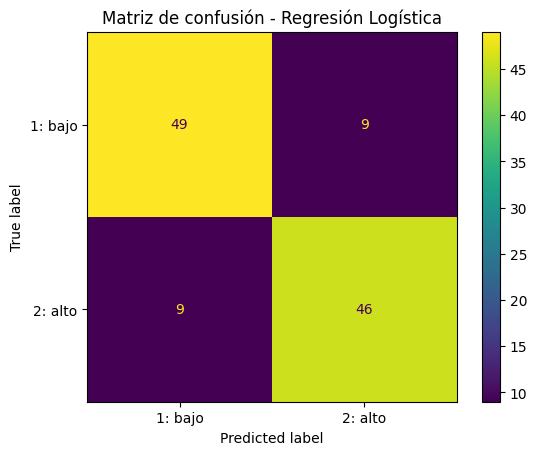

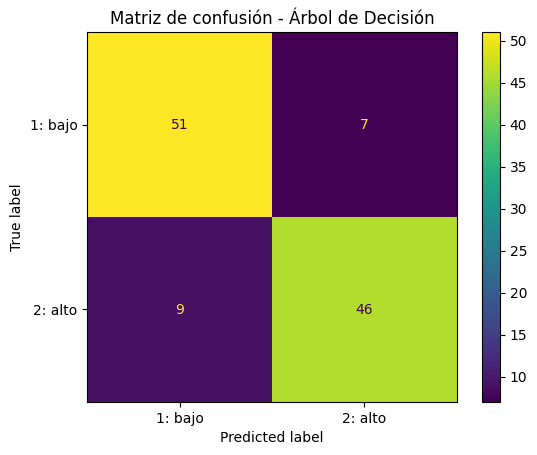

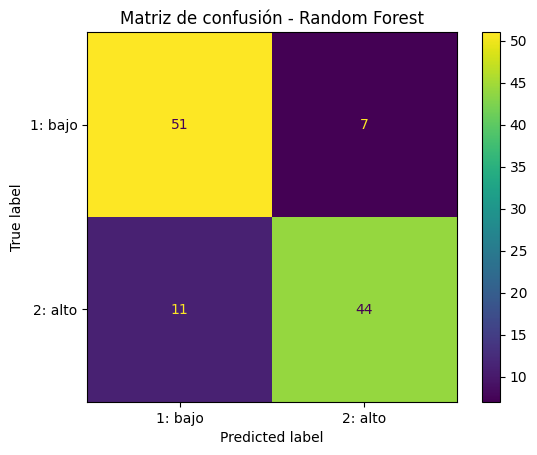

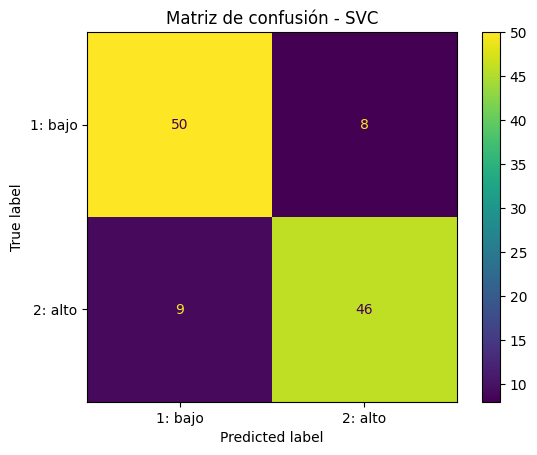

In [20]:
for nombre, cm in matrices_confusion.items():
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['1: bajo', '2: alto']
    )

    disp.plot(values_format='d')
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()

## 11. Grupos reales vs grupos predichos

Ahora vamos a comparar cuántos registros reales había en cada clase y cuántos predijo cada modelo.

Esto no reemplaza la matriz de confusión, pero ayuda a ver si un modelo tiende a predecir demasiados casos como salario bajo o demasiados casos como salario alto.



Modelo: Regresión Logística


,Real,Predicho
1: salario_bajo,58,58
2: salario_alto,55,55


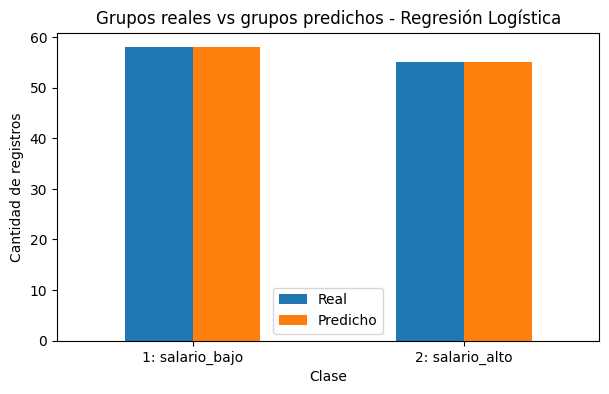


Modelo: Árbol de Decisión


,Real,Predicho
1: salario_bajo,58,60
2: salario_alto,55,53


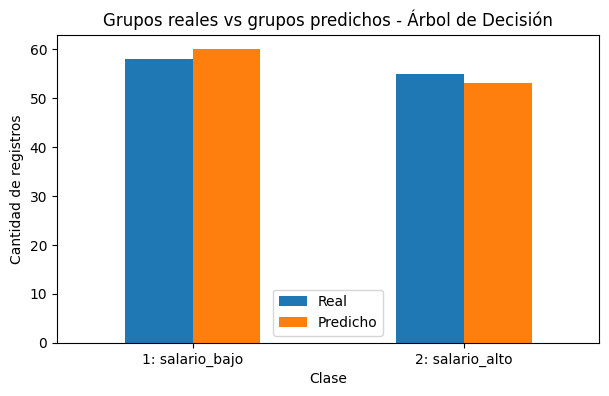


Modelo: Random Forest


,Real,Predicho
1: salario_bajo,58,62
2: salario_alto,55,51


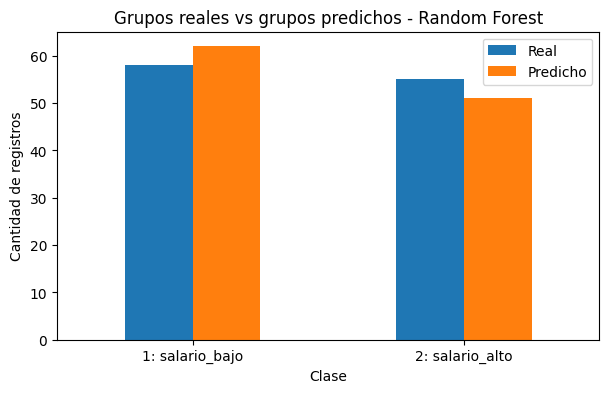


Modelo: SVC


,Real,Predicho
1: salario_bajo,58,59
2: salario_alto,55,54


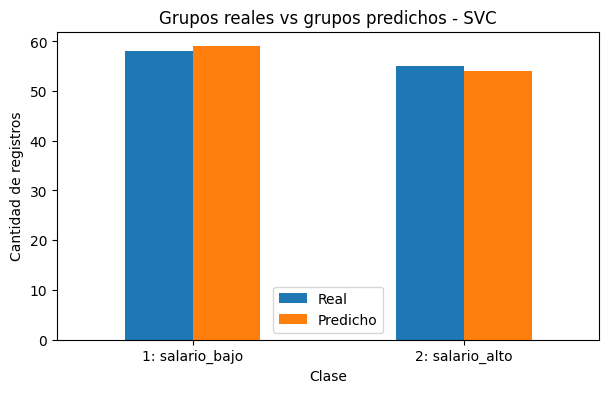

In [21]:
etiquetas = [1, 2]
nombres_etiquetas = {
    1: '1: salario_bajo',
    2: '2: salario_alto'
}

conteo_real = pd.Series(y_test).value_counts().reindex(etiquetas, fill_value=0)
conteo_real.index = [nombres_etiquetas[i] for i in etiquetas]

for nombre, y_pred in predicciones.items():
    conteo_predicho = pd.Series(y_pred).value_counts().reindex(etiquetas, fill_value=0)
    conteo_predicho.index = [nombres_etiquetas[i] for i in etiquetas]

    comparacion = pd.DataFrame({
        'Real': conteo_real,
        'Predicho': conteo_predicho
    })

    print(f'\nModelo: {nombre}')
    display(comparacion)

    comparacion.plot(kind='bar', figsize=(7, 4))
    plt.title(f'Grupos reales vs grupos predichos - {nombre}')
    plt.xlabel('Clase')
    plt.ylabel('Cantidad de registros')
    plt.xticks(rotation=0)
    plt.show()


## 12. Reporte de clasificación

El reporte de clasificación muestra métricas adicionales como precisión, recall y F1-score.

Para este ejercicio, la métrica central será accuracy, pero el reporte ayuda a observar si el modelo se comporta de forma equilibrada en ambas clases.


In [22]:
for nombre, y_pred in predicciones.items():
    print('=' * 70)
    print(nombre)
    print(classification_report(
        y_test,
        y_pred,
        labels=[1, 2],
        target_names=['1: salario_bajo', '2: salario_alto']
    ))

Regresión Logística
                 precision    recall  f1-score   support

1: salario_bajo       0.84      0.84      0.84        58
2: salario_alto       0.84      0.84      0.84        55

       accuracy                           0.84       113
      macro avg       0.84      0.84      0.84       113
   weighted avg       0.84      0.84      0.84       113

Árbol de Decisión
                 precision    recall  f1-score   support

1: salario_bajo       0.85      0.88      0.86        58
2: salario_alto       0.87      0.84      0.85        55

       accuracy                           0.86       113
      macro avg       0.86      0.86      0.86       113
   weighted avg       0.86      0.86      0.86       113

Random Forest
                 precision    recall  f1-score   support

1: salario_bajo       0.82      0.88      0.85        58
2: salario_alto       0.86      0.80      0.83        55

       accuracy                           0.84       113
      macro avg       0.84  

## 13. Seleccionar y guardar el mejor modelo

Seleccionaremos el mejor modelo según el mayor valor de **accuracy**.

Después lo guardaremos con `joblib` para poder cargarlo en otro ejercicio y usarlo para hacer predicciones.


In [23]:
mejor_nombre = resultados_df.iloc[0]['modelo']
mejor_accuracy = resultados_df.iloc[0]['accuracy']
mejor_modelo = modelos[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'Accuracy: {mejor_accuracy * 100:.2f}%')

Mejor modelo: Árbol de Decisión
Accuracy: 85.84%


In [26]:
paquete_modelo = {
    'modelo': mejor_modelo,
    'mediana_salario': mediana_salario,
    'columnas_entrada': X.columns.tolist(),
    'clases': {
        1: 'salario_bajo',
        2: 'salario_alto'
    },
    'criterio': '1 = salary_in_usd <= mediana; 2 = salary_in_usd > mediana'
}

joblib.dump(paquete_modelo, '/content/drive/MyDrive/bootcamp_ia_2026-1/modeloClasificacion.pkl')

print('Modelo guardado como: modeloClasificacion.pkl')

Modelo guardado como: modeloClasificacion.pkl


In [ ]:
resultados_df.to_csv('metricas_modelos_clasificacion_salarios.csv', index=False)
print('Métricas guardadas como: metricas_modelos_clasificacion_salarios.csv')

Métricas guardadas como: metricas_modelos_clasificacion_salarios.csv


## 14. Ejemplo de uso del modelo guardado

Este ejemplo muestra cómo cargar el modelo guardado y hacer una predicción para un nuevo caso.

La predicción devuelve:

- `1`: salario_bajo;
- `2`: salario_alto.


In [27]:
paquete_cargado = joblib.load('/content/drive/MyDrive/bootcamp_ia_2026-1/modeloClasificacion.pkl')
modelo_cargado = paquete_cargado['modelo']

nuevo_caso = pd.DataFrame([{
    'work_year': 2022,
    'experience_level': 'SE',
    'employment_type': 'FT',
    'job_title': 'Data Scientist',
    'employee_residence': 'US',
    'remote_ratio': 100,
    'company_location': 'US',
    'company_size': 'M'
}])

prediccion = modelo_cargado.predict(nuevo_caso)[0]
nombre_prediccion = paquete_cargado['clases'][prediccion]

print('Etiqueta predicha:', prediccion)
print('Clase predicha:', nombre_prediccion)

Etiqueta predicha: 2
Clase predicha: salario_alto


## 15. Conclusión del análisis

En este notebook se transformó un problema de regresión en un problema de clasificación. En lugar de predecir el salario exacto, se buscó clasificar cada registro como **salario bajo** o **salario alto**.

El punto de corte fue la mediana del salario en USD. Este criterio funcionó bien para una práctica exploratoria porque generó dos grupos balanceados.

Los modelos comparados fueron:

- Regresión Logística;
- Árbol de Decisión;
- Random Forest;
- SVC.

Para mantener el ejercicio claro, todos los modelos usaron el mismo preprocesamiento:

- `OrdinalEncoder` para variables con orden lógico;
- `OneHotEncoder` para variables nominales;
- `work_year` sin transformación.

La matriz de confusión permitió revisar no solo cuántos casos acertó cada modelo, sino también en qué tipo de error cayó: salarios bajos clasificados como altos o salarios altos clasificados como bajos.

En general, el enfoque de clasificación resultó adecuado para esta base, porque las clases quedaron equilibradas y los modelos lograron distinguir razonablemente entre salarios bajos y altos.

La conclusión más importante para clase es:

> Cambiar el paradigma de regresión a clasificación puede hacer que el problema sea más fácil de interpretar. En vez de estimar un valor exacto de salario, el modelo aprende a separar perfiles en dos grupos: salario bajo y salario alto. Esto permite explicar de forma clara conceptos como variable objetivo, balanceo de clases, partición de datos, preprocesamiento, entrenamiento, accuracy y matriz de confusión.
